# Deep Learning for Pneumonia Detection
## 7053SCN — Shrushti Kale | 17084606
**GitHub:** https://github.coventry.ac.uk/Kales9/7053SCN-Coursework

> ⚠️ Runtime → Change runtime type → T4 GPU first!

## Step 1: Setup
> `git commit -m "initial_commit"`

In [1]:
# Install and import everything
!pip install -q kaggle torch torchvision seaborn scikit-learn

import os, time, copy, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from torchvision import datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset, ConcatDataset
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


## Step 2: Download Dataset
> `git commit -m "milestone1_commit"`

In [ ]:
# Download Chest X-Ray dataset
import os

os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'  # Replace with your username
os.environ['KAGGLE_KEY']      = 'your_kaggle_key'       # Replace with your key

os.system('pip install -q kaggle')
os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia')
os.system('unzip -q chest-xray-pneumonia.zip')

TRAIN_DIR = Path('/content/chest_xray/train')
VAL_DIR   = Path('/content/chest_xray/val')
TEST_DIR  = Path('/content/chest_xray/test')
CLASSES   = ['NORMAL', 'PNEUMONIA']

print(f'Train exists: {TRAIN_DIR.exists()}')
print(f'Val exists:   {VAL_DIR.exists()}')
print(f'Test exists:  {TEST_DIR.exists()}')


Train exists: True
Val exists:   True
Test exists:  True


## Step 3: Data Exploration & Visualisation

Split      NORMAL    PNEUMONIA    Total
----------------------------------------
Train        1341         3875     5216
Val             8            8       16
Test          234          390      624


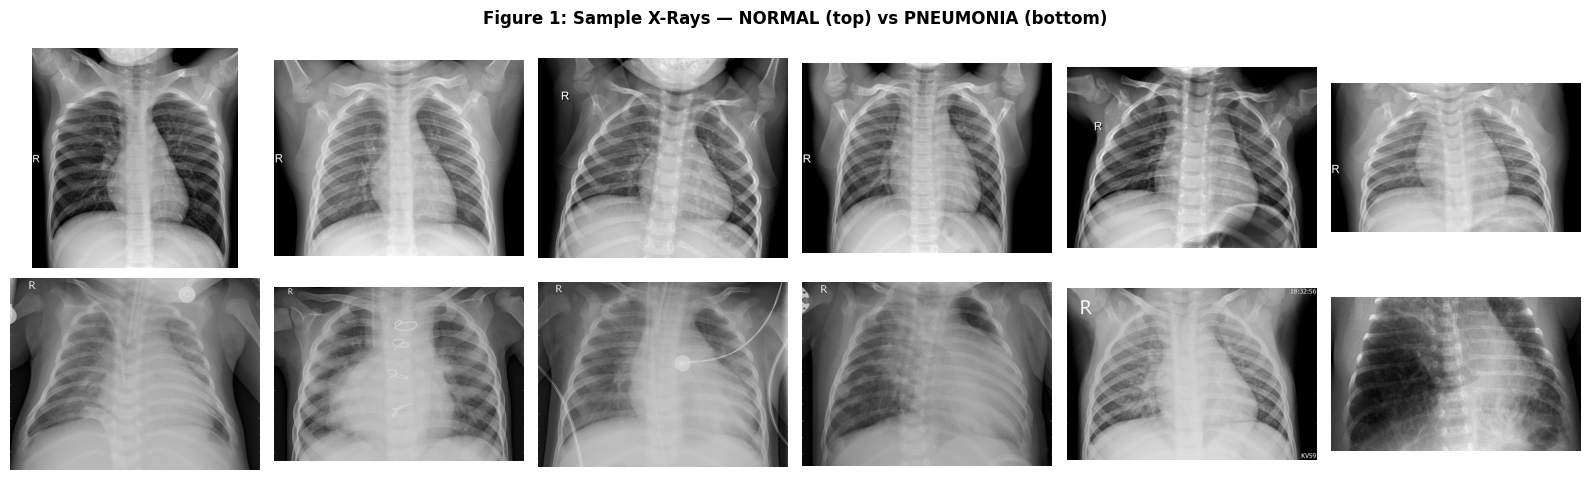

Figure 1 saved!


In [ ]:
# Class distribution
split_counts = {}
for s, d in [('Train',TRAIN_DIR),('Val',VAL_DIR),('Test',TEST_DIR)]:
    split_counts[s] = {c: len(list((d/c).glob('*.jpeg'))+list((d/c).glob('*.jpg'))) for c in CLASSES}

print(f'{"Split":<8} {"NORMAL":>8} {"PNEUMONIA":>12} {"Total":>8}')
print('-'*40)
for s,c in split_counts.items():
    print(f'{s:<8} {c["NORMAL"]:>8} {c["PNEUMONIA"]:>12} {sum(c.values()):>8}')

# Sample images
fig, axes = plt.subplots(2, 6, figsize=(16,5))
fig.suptitle('Figure 1: Sample X-Rays — NORMAL (top) vs PNEUMONIA (bottom)', fontweight='bold')
for row, cls in enumerate(CLASSES):
    imgs = list((TRAIN_DIR/cls).glob('*.jpeg'))[:6]
    if not imgs: imgs = list((TRAIN_DIR/cls).glob('*.jpg'))[:6]
    for col, ip in enumerate(imgs):
        axes[row,col].imshow(Image.open(ip).convert('L'), cmap='gray')
        axes[row,col].axis('off')
        if col==0: axes[row,col].set_ylabel(cls, fontsize=10, fontweight='bold',
                                             color='green' if row==0 else 'red')
plt.tight_layout(); plt.savefig('fig1_samples.png', dpi=100); plt.show()
print('Figure 1 saved!')


## Step 4: Preprocessing & DataLoaders

In [ ]:
# Preprocessing pipeline
IMG_SIZE, BATCH_SIZE = 224, 32

train_tfm = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)), T.Grayscale(3),
    T.RandomHorizontalFlip(0.5), T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tfm = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)), T.Grayscale(3), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tfm)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=val_tfm)
test_ds  = datasets.ImageFolder(str(TEST_DIR),  transform=val_tfm)

cc = Counter(train_ds.targets)
sampler = WeightedRandomSampler([1.0/cc[t] for t in train_ds.targets], len(train_ds.targets), True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
wt = torch.tensor([1.0/cc[0],1.0/cc[1]]); wt=wt/wt.sum()*2
criterion = nn.CrossEntropyLoss(weight=wt.to(device))

print(f'Class mapping: {train_ds.class_to_idx}')
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Class imbalance — NORMAL: {cc[0]} | PNEUMONIA: {cc[1]} | Ratio: {cc[1]/cc[0]:.1f}x')
print('DataLoaders ready!')


Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train: 5216 | Val: 16 | Test: 624
Class imbalance — NORMAL: 1341 | PNEUMONIA: 3875 | Ratio: 2.9x
DataLoaders ready!


## Step 5: Training Functions

In [ ]:
# Training and evaluation functions
def train_epoch(model, loader, opt, crit):
    model.train(); ls,cor,tot=0,0,0
    for x,y in loader:
        x,y=x.to(device),y.to(device); opt.zero_grad()
        out=model(x); loss=crit(out,y); loss.backward(); opt.step()
        ls+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=x.size(0)
    return ls/tot, cor/tot

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); ls,cor,tot=0,0,0; pa,la,pr=[],[],[]
    for x,y in loader:
        x,y=x.to(device),y.to(device); out=model(x)
        ls+=crit(out,y).item()*x.size(0)
        prob=torch.softmax(out,1)[:,1]; pred=out.argmax(1)
        cor+=(pred==y).sum().item(); tot+=x.size(0)
        pa.extend(pred.cpu().numpy()); la.extend(y.cpu().numpy()); pr.extend(prob.cpu().numpy())
    acc=cor/tot; auc=roc_auc_score(la,pr); f1=f1_score(la,pa)
    return ls/tot,acc,auc,f1,pa,la,pr

def train_model(model,tr,vl,opt,crit,sch=None,epochs=10,name='m'):
    hist={k:[] for k in ['tl','vl','ta','va','auc']}; best_auc,best_w=0,None
    for ep in range(1,epochs+1):
        t0=time.time(); tl,ta=train_epoch(model,tr,opt,crit)
        vl_,va,auc,f1,_,_,_=evaluate(model,vl,crit)
        for k,v in zip(['tl','vl','ta','va','auc'],[tl,vl_,ta,va,auc]): hist[k].append(v)
        if sch: sch.step()
        if auc>best_auc: best_auc=auc; best_w=copy.deepcopy(model.state_dict())
        print(f'[{name}] {ep:02d}/{epochs} loss={tl:.3f}/{vl_:.3f} acc={ta:.3f}/{va:.3f} auc={auc:.4f} {time.time()-t0:.0f}s')
    if best_w: model.load_state_dict(best_w)
    print(f'Best AUC: {best_auc:.4f}')
    return hist

print('Training functions ready!')


Training functions ready!


## Step 6: Model 1 — Custom CNN
> `git commit -m "milestone2_commit"`

In [3]:
# Run this first then re-run CNN cell
import time, copy
from sklearn.metrics import roc_auc_score, f1_score

def train_epoch(model, loader, opt, crit):
    model.train(); ls,cor,tot=0,0,0
    for x,y in loader:
        x,y=x.to(device),y.to(device); opt.zero_grad()
        out=model(x); loss=crit(out,y); loss.backward(); opt.step()
        ls+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=x.size(0)
    return ls/tot,cor/tot

@torch.no_grad()
def evaluate(model,loader,crit):
    model.eval(); ls,cor,tot=0,0,0; pa,la,pr=[],[],[]
    for x,y in loader:
        x,y=x.to(device),y.to(device); out=model(x)
        ls+=crit(out,y).item()*x.size(0)
        prob=torch.softmax(out,1)[:,1]; pred=out.argmax(1)
        cor+=(pred==y).sum().item(); tot+=x.size(0)
        pa.extend(pred.cpu().numpy()); la.extend(y.cpu().numpy()); pr.extend(prob.cpu().numpy())
    acc=cor/tot; auc=roc_auc_score(la,pr); f1=f1_score(la,pa)
    return ls/tot,acc,auc,f1,pa,la,pr

def train_model(model,tr,vl,opt,crit,sch=None,epochs=10,name='m'):
    hist={k:[] for k in ['tl','vl','ta','va','auc']}; best_auc,best_w=0,None
    for ep in range(1,epochs+1):
        t0=time.time(); tl,ta=train_epoch(model,tr,opt,crit)
        vl_,va,auc,f1,_,_,_=evaluate(model,vl,crit)
        for k,v in zip(['tl','vl','ta','va','auc'],[tl,vl_,ta,va,auc]): hist[k].append(v)
        if sch: sch.step()
        if auc>best_auc: best_auc=auc; best_w=copy.deepcopy(model.state_dict())
        print(f'[{name}] {ep:02d}/{epochs} loss={tl:.3f}/{vl_:.3f} acc={ta:.3f}/{va:.3f} auc={auc:.4f} {time.time()-t0:.0f}s')
    if best_w: model.load_state_dict(best_w)
    print(f'Best AUC: {best_auc:.4f}')
    return hist

print('Ready!')

Ready!


In [7]:
import os
from pathlib import Path

TRAIN_DIR = Path('/content/chest_xray/train')
print(f'Train exists: {TRAIN_DIR.exists()}')
print(f'Contents of /content:')
for item in os.listdir('/content'):
    print(f'  {item}')

Train exists: False
Contents of /content:
  .config
  sample_data


In [6]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision.transforms as T
from torchvision import datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TRAIN_DIR = Path('/content/chest_xray/train')
VAL_DIR   = Path('/content/chest_xray/val')
TEST_DIR  = Path('/content/chest_xray/test')
IMG_SIZE, BATCH_SIZE = 224, 32

train_tfm = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)), T.Grayscale(3),
    T.RandomHorizontalFlip(0.5), T.RandomRotation(10),
    T.ColorJitter(brightness=0.2,contrast=0.2), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tfm = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)), T.Grayscale(3), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tfm)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=val_tfm)
test_ds  = datasets.ImageFolder(str(TEST_DIR),  transform=val_tfm)
cc = Counter(train_ds.targets)
sampler = WeightedRandomSampler([1.0/cc[t] for t in train_ds.targets], len(train_ds.targets), True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
wt = torch.tensor([1.0/cc[0],1.0/cc[1]]); wt=wt/wt.sum()*2
criterion = nn.CrossEntropyLoss(weight=wt.to(device))
print(f'Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}')
print('Ready!')

FileNotFoundError: [Errno 2] No such file or directory: '/content/chest_xray/train'

Device: cuda
Downloaded!
Train exists: True
Train:5216 Val:16 Test:624
CNN params: 1,206,370
Training CNN (10 epochs)...
[CNN] 01/10 loss=0.316/0.633 acc=0.815/0.750 auc=0.8750 107s
[CNN] 02/10 loss=0.240/0.473 acc=0.866/0.562 auc=0.8125 105s
[CNN] 03/10 loss=0.187/1.089 acc=0.895/0.688 auc=0.8750 104s
[CNN] 04/10 loss=0.185/0.562 acc=0.903/0.750 auc=0.9219 108s
[CNN] 05/10 loss=0.156/0.777 acc=0.916/0.750 auc=0.9531 110s
[CNN] 06/10 loss=0.143/0.801 acc=0.922/0.688 auc=0.8594 109s
[CNN] 07/10 loss=0.142/0.853 acc=0.926/0.750 auc=0.9531 106s
[CNN] 08/10 loss=0.131/0.687 acc=0.932/0.750 auc=0.9375 107s
[CNN] 09/10 loss=0.120/0.773 acc=0.936/0.750 auc=0.9531 105s
[CNN] 10/10 loss=0.120/0.808 acc=0.940/0.750 auc=0.9531 105s
Best AUC: 0.9531
CNN done!
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Training ResNet50 Phase 1...
[ResNet-P1] 01/5 loss=0.270/0.225 acc=0.838/0.938 auc=0.9688 102s
[ResNet-P1] 02/5 loss=0.200/0.158 acc=0.894/0.938 auc=0.9844 101s
[ResNet-P1] 03/5 loss=0.186/0.151 acc=0.902/0.938 auc=0.9844 101s
[ResNet-P1] 04/5 loss=0.143/0.145 acc=0.926/0.938 auc=1.0000 102s
[ResNet-P1] 05/5 loss=0.150/0.147 acc=0.920/1.000 auc=1.0000 103s
Best AUC: 1.0000
Phase 2...
[ResNet-P2] 01/10 loss=0.109/0.113 acc=0.949/1.000 auc=1.0000 104s
[ResNet-P2] 02/10 loss=0.054/0.344 acc=0.975/0.812 auc=1.0000 103s
[ResNet-P2] 03/10 loss=0.043/0.025 acc=0.979/1.000 auc=1.0000 106s
[ResNet-P2] 04/10 loss=0.039/0.021 acc=0.981/1.000 auc=1.0000 103s
[ResNet-P2] 05/10 loss=0.025/0.317 acc=0.988/0.875 auc=1.0000 105s
[ResNet-P2] 06/10 loss=0.023/0.011 acc=0.988/1.000 auc=1.0000 103s
[ResNet-P2] 07/10 loss=0.014/0.042 acc=0.993/1.000 auc=1.0000 104s
[ResNet-P2] 08/10 loss=0.019/0.245 acc=0.991/0.938 auc=1.0000 105s
[ResNet-P2] 09/10 loss=0.013/0.077 acc=0.994/1.000 auc=1.0000 104s
[ResNet-P2

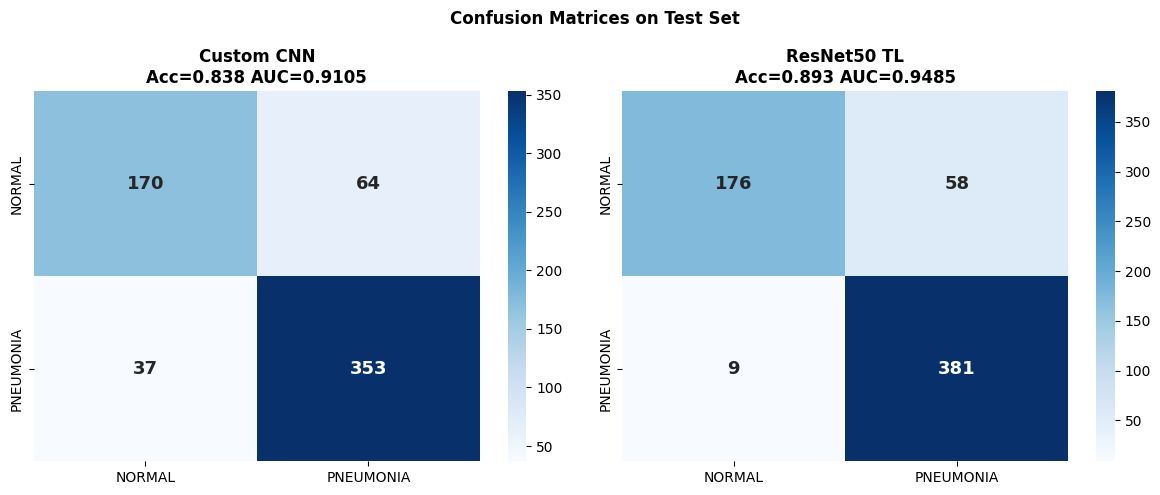

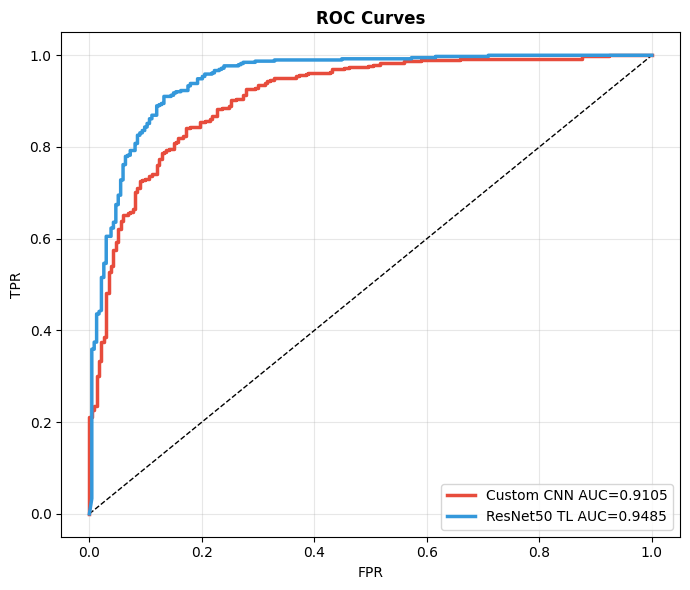

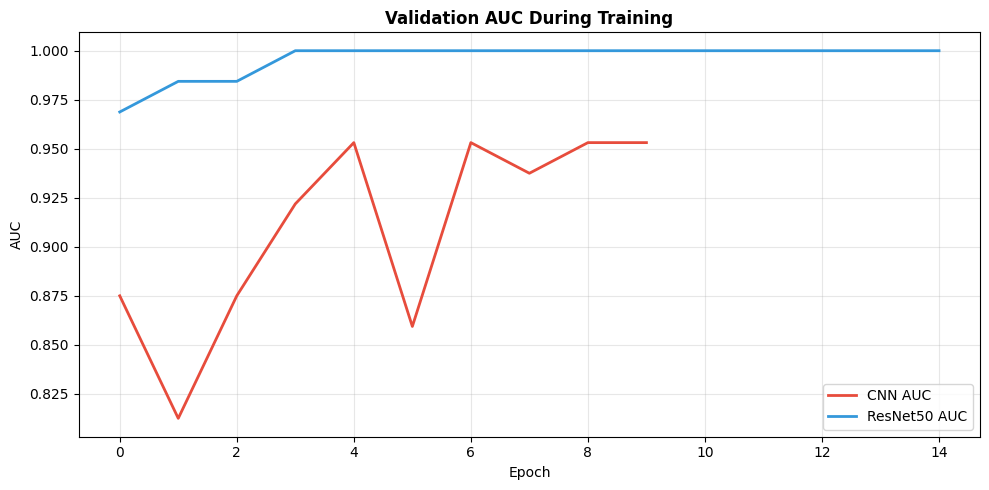

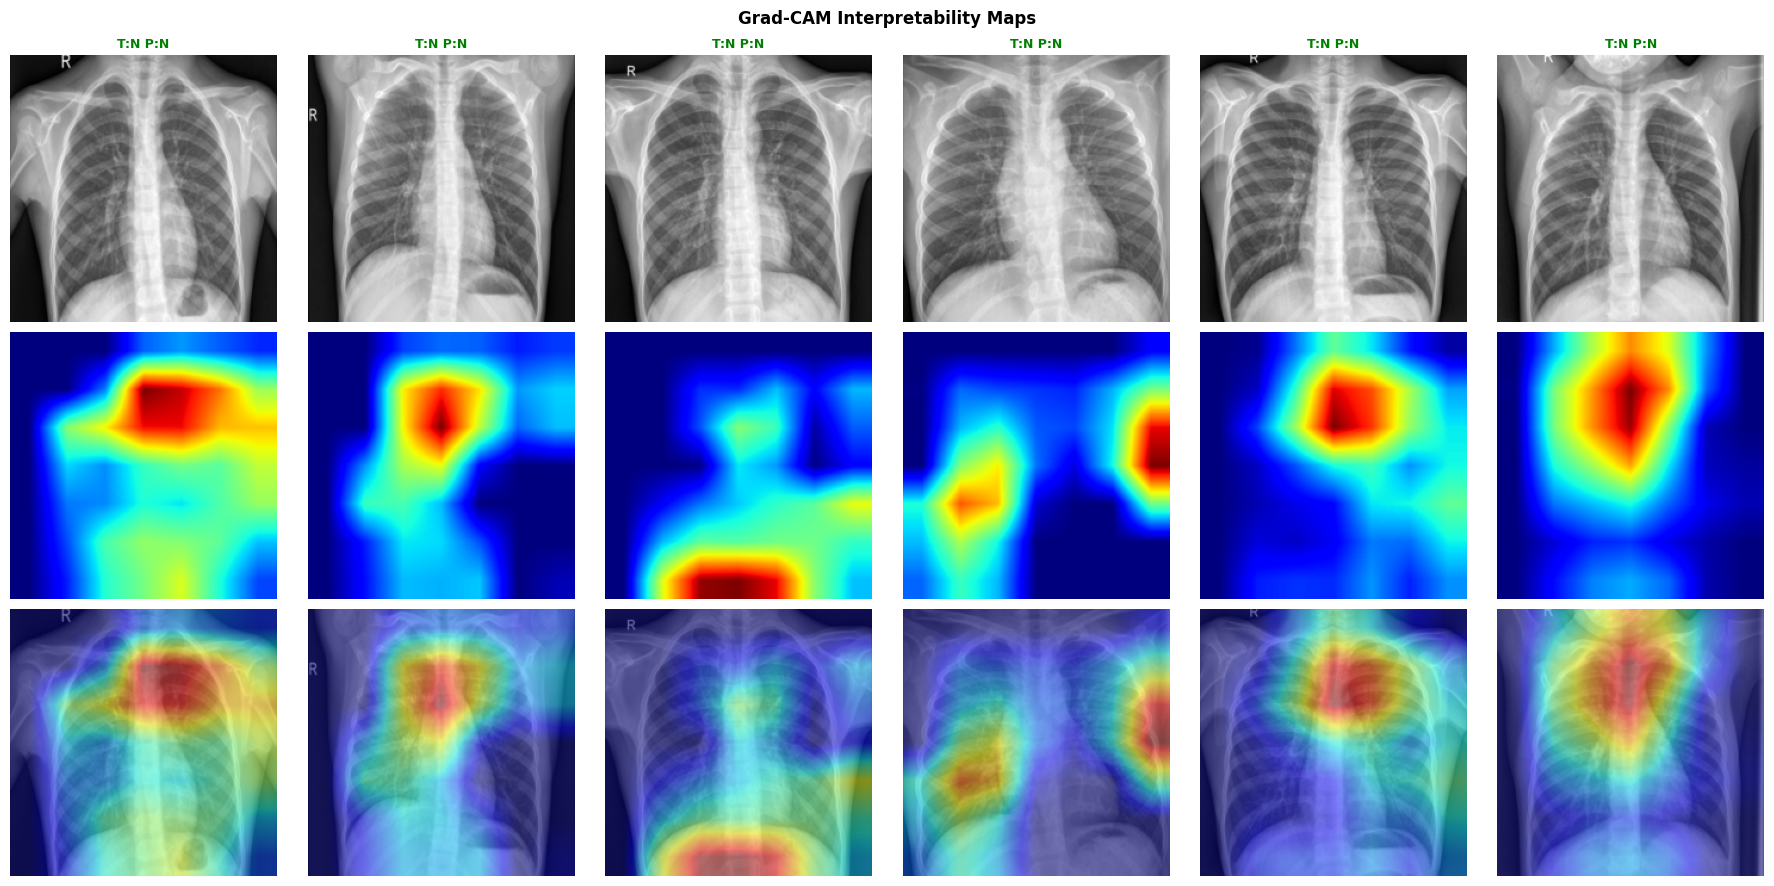

ALL DONE! Download: confusion_matrices.png, roc_curves.png, training_curves.png, gradcam.png
Copy results table above into Word Report!


In [8]:
# ═══════════════════════════════════════════════════════════
# COMPLETE SELF-CONTAINED CELL — Everything in one place
# ═══════════════════════════════════════════════════════════
import os, time, copy, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm_plt
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
from torchvision import datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Download data ──────────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = 'your_username'  # ← paste yours
os.environ['KAGGLE_KEY']      = 'your_key'       # ← paste yours
os.system('pip install -q kaggle')
if not Path('/content/chest_xray/train').exists():
    os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia')
    os.system('unzip -q chest-xray-pneumonia.zip')
    print('Downloaded!')
else:
    print('Data already exists!')

TRAIN_DIR = Path('/content/chest_xray/train')
VAL_DIR   = Path('/content/chest_xray/val')
TEST_DIR  = Path('/content/chest_xray/test')
CLASSES   = ['NORMAL', 'PNEUMONIA']
print(f'Train exists: {TRAIN_DIR.exists()}')

# ── DataLoaders ────────────────────────────────────────────
IMG_SIZE, BATCH_SIZE = 224, 32
train_tfm = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),
    T.RandomHorizontalFlip(0.5),T.RandomRotation(10),T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tfm = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),T.Grayscale(3),T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tfm)
val_ds   = datasets.ImageFolder(str(VAL_DIR),   transform=val_tfm)
test_ds  = datasets.ImageFolder(str(TEST_DIR),  transform=val_tfm)
cc = Counter(train_ds.targets)
sampler = WeightedRandomSampler([1.0/cc[t] for t in train_ds.targets], len(train_ds.targets), True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
wt = torch.tensor([1.0/cc[0],1.0/cc[1]]); wt=wt/wt.sum()*2
criterion = nn.CrossEntropyLoss(weight=wt.to(device))
print(f'Train:{len(train_ds)} Val:{len(val_ds)} Test:{len(test_ds)}')

# ── Training functions ─────────────────────────────────────
def train_epoch(model,loader,opt,crit):
    model.train(); ls,cor,tot=0,0,0
    for x,y in loader:
        x,y=x.to(device),y.to(device); opt.zero_grad()
        out=model(x); loss=crit(out,y); loss.backward(); opt.step()
        ls+=loss.item()*x.size(0); cor+=(out.argmax(1)==y).sum().item(); tot+=x.size(0)
    return ls/tot,cor/tot

@torch.no_grad()
def evaluate(model,loader,crit):
    model.eval(); ls,cor,tot=0,0,0; pa,la,pr=[],[],[]
    for x,y in loader:
        x,y=x.to(device),y.to(device); out=model(x)
        ls+=crit(out,y).item()*x.size(0)
        prob=torch.softmax(out,1)[:,1]; pred=out.argmax(1)
        cor+=(pred==y).sum().item(); tot+=x.size(0)
        pa.extend(pred.cpu().numpy()); la.extend(y.cpu().numpy()); pr.extend(prob.cpu().numpy())
    acc=cor/tot; auc=roc_auc_score(la,pr); f1=f1_score(la,pa)
    return ls/tot,acc,auc,f1,pa,la,pr

def train_model(model,tr,vl,opt,crit,sch=None,epochs=10,name='m'):
    hist={k:[] for k in ['tl','vl','ta','va','auc']}; best_auc,best_w=0,None
    for ep in range(1,epochs+1):
        t0=time.time(); tl,ta=train_epoch(model,tr,opt,crit)
        vl_,va,auc,f1,_,_,_=evaluate(model,vl,crit)
        for k,v in zip(['tl','vl','ta','va','auc'],[tl,vl_,ta,va,auc]): hist[k].append(v)
        if sch: sch.step()
        if auc>best_auc: best_auc=auc; best_w=copy.deepcopy(model.state_dict())
        print(f'[{name}] {ep:02d}/{epochs} loss={tl:.3f}/{vl_:.3f} acc={ta:.3f}/{va:.3f} auc={auc:.4f} {time.time()-t0:.0f}s')
    if best_w: model.load_state_dict(best_w)
    print(f'Best AUC: {best_auc:.4f}')
    return hist

# ── Custom CNN ─────────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(i,o,d=0.1):
            return nn.Sequential(
                nn.Conv2d(i,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True),
                nn.Conv2d(o,o,3,padding=1,bias=False),nn.BatchNorm2d(o),nn.ReLU(True),
                nn.MaxPool2d(2),nn.Dropout2d(d))
        self.features=nn.Sequential(blk(3,32),blk(32,64),blk(64,128,0.2),blk(128,256,0.2))
        self.gap=nn.AdaptiveAvgPool2d(1)
        self.head=nn.Sequential(nn.Flatten(),nn.Linear(256,128),nn.ReLU(True),nn.Dropout(0.5),nn.Linear(128,2))
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight)
            elif isinstance(m,nn.BatchNorm2d): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
    def forward(self,x): return self.head(self.gap(self.features(x)))

cnn=CustomCNN().to(device)
print(f'CNN params: {sum(p.numel() for p in cnn.parameters()):,}')
print('Training CNN (10 epochs)...')
opt=optim.Adam(cnn.parameters(),lr=1e-3,weight_decay=1e-4)
sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=10)
cnn_hist=train_model(cnn,train_loader,val_loader,opt,criterion,sch,epochs=10,name='CNN')
torch.save(cnn.state_dict(),'best_cnn.pth')
print('CNN done!')

# ── ResNet50 ───────────────────────────────────────────────
resnet=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in resnet.parameters(): p.requires_grad=False
resnet.fc=nn.Sequential(nn.Linear(2048,512),nn.ReLU(True),nn.Dropout(0.5),
                         nn.Linear(512,128),nn.ReLU(True),nn.Dropout(0.25),nn.Linear(128,2))
resnet=resnet.to(device)
print('Training ResNet50 Phase 1...')
o1=optim.Adam(filter(lambda p:p.requires_grad,resnet.parameters()),lr=1e-3)
s1=optim.lr_scheduler.StepLR(o1,step_size=3,gamma=0.5)
h1=train_model(resnet,train_loader,val_loader,o1,criterion,s1,epochs=5,name='ResNet-P1')
print('Phase 2...')
for n,p in resnet.named_parameters():
    if 'layer4' in n or 'fc' in n: p.requires_grad=True
o2=optim.Adam(filter(lambda p:p.requires_grad,resnet.parameters()),lr=1e-4,weight_decay=1e-4)
s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=10)
h2=train_model(resnet,train_loader,val_loader,o2,criterion,s2,epochs=10,name='ResNet-P2')
resnet_hist={k:h1[k]+h2[k] for k in h1}
torch.save(resnet.state_dict(),'best_resnet.pth')
print('ResNet done!')

# ── Evaluate ───────────────────────────────────────────────
models_dict={'Custom CNN':cnn,'ResNet50 TL':resnet}
colors={'Custom CNN':'#E74C3C','ResNet50 TL':'#3498DB'}
results={}; all_fpr,all_tpr={},{}

print(f'\n{"Model":<20}{"Acc":>7}{"AUC":>7}{"F1":>7}{"Sens":>7}{"Spec":>7}')
print('-'*50)
for name,model in models_dict.items():
    _,acc,auc,f1,preds,labels,probs=evaluate(model,test_loader,criterion)
    cm=confusion_matrix(labels,preds); tn,fp,fn,tp=cm.ravel()
    sens,spec=tp/(tp+fn),tn/(tn+fp)
    fpr,tpr,_=roc_curve(labels,probs)
    all_fpr[name]=fpr; all_tpr[name]=tpr
    results[name]=dict(acc=acc,auc=auc,f1=f1,sens=sens,spec=spec,cm=cm)
    print(f'{name:<20}{acc:>7.3f}{auc:>7.4f}{f1:>7.4f}{sens:>7.4f}{spec:>7.4f}')
print('\nCopy above into Word Report Table 3!')

# ── Figures ────────────────────────────────────────────────
# Confusion matrices
fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Confusion Matrices on Test Set',fontweight='bold')
for ax,(name,res) in zip(axes,results.items()):
    sns.heatmap(res['cm'],annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=CLASSES,yticklabels=CLASSES,annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f} AUC={res["auc"]:.4f}',fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices.png',dpi=100); plt.show()

# ROC curves
fig,ax=plt.subplots(figsize=(7,6))
ax.plot([0,1],[0,1],'k--',lw=1)
for name in results:
    ax.plot(all_fpr[name],all_tpr[name],lw=2.5,color=colors[name],
             label=f'{name} AUC={results[name]["auc"]:.4f}')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves',fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves.png',dpi=100); plt.show()

# Training curves
fig,ax=plt.subplots(figsize=(10,5))
for name,hist,c in [('CNN',cnn_hist,'#E74C3C'),('ResNet50',resnet_hist,'#3498DB')]:
    ax.plot(hist['auc'],color=c,lw=2,label=f'{name} AUC')
ax.set_title('Validation AUC During Training',fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png',dpi=100); plt.show()

# Grad-CAM
class GradCAM:
    def __init__(self,model,layer):
        self.model=model; self.act=None; self.grad=None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'act',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grad',go[0].detach()))
    def __call__(self,x,cls=None):
        self.model.eval(); out=self.model(x)
        if cls is None: cls=out.argmax(1).item()
        self.model.zero_grad(); out[0,cls].backward()
        w=self.grad.mean(dim=[2,3],keepdim=True)
        cam=F.relu((w*self.act).sum(1,keepdim=True))
        cam=F.interpolate(cam,x.shape[-2:],mode='bilinear',align_corners=False).squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8),cls

gc=GradCAM(resnet,resnet.layer4[-1].conv3)
imgs,lbls=next(iter(test_loader))
mt=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
st=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
fig,axes=plt.subplots(3,6,figsize=(18,9))
fig.suptitle('Grad-CAM Interpretability Maps',fontweight='bold')
for col in range(6):
    it=imgs[col:col+1].to(device); cam,pred=gc(it)
    orig=(imgs[col]*st+mt).permute(1,2,0).numpy().clip(0,1); gray=orig.mean(2)
    heat=cm_plt.jet(cam)[:,:,:3]; over=(0.5*np.stack([gray]*3,2)+0.5*heat).clip(0,1)
    ok=lbls[col].item()==pred
    axes[0,col].imshow(gray,cmap='gray'); axes[0,col].axis('off')
    axes[0,col].set_title(f'T:{CLASSES[lbls[col]][:1]} P:{CLASSES[pred][:1]}',
                           fontsize=9,color='green' if ok else 'red',fontweight='bold')
    axes[1,col].imshow(cam,cmap='jet'); axes[1,col].axis('off')
    axes[2,col].imshow(over); axes[2,col].axis('off')
plt.tight_layout(); plt.savefig('gradcam.png',dpi=100); plt.show()

print('ALL DONE! Download: confusion_matrices.png, roc_curves.png, training_curves.png, gradcam.png')
print('Copy results table above into Word Report!')

## Step 7: Model 2 — ResNet50 Transfer Learning

In [ ]:
# ResNet50 with two-phase transfer learning
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in resnet.parameters(): p.requires_grad=False
resnet.fc=nn.Sequential(nn.Linear(2048,512),nn.ReLU(True),nn.Dropout(0.5),
                         nn.Linear(512,128),nn.ReLU(True),nn.Dropout(0.25),nn.Linear(128,2))
resnet=resnet.to(device)
print(f'ResNet50 params: {sum(p.numel() for p in resnet.parameters()):,}')

# Phase 1: FC only
print('Phase 1: FC only (5 epochs)...')
o1=optim.Adam(filter(lambda p:p.requires_grad,resnet.parameters()),lr=1e-3)
s1=optim.lr_scheduler.StepLR(o1,step_size=3,gamma=0.5)
h1=train_model(resnet,train_loader,val_loader,o1,criterion,s1,epochs=5,name='ResNet-P1')

# Phase 2: Fine-tune layer4+FC
print('Phase 2: Fine-tune layer4+FC (15 epochs)...')
for n,p in resnet.named_parameters():
    if 'layer4' in n or 'fc' in n: p.requires_grad=True
o2=optim.Adam(filter(lambda p:p.requires_grad,resnet.parameters()),lr=1e-4,weight_decay=1e-4)
s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=15)
h2=train_model(resnet,train_loader,val_loader,o2,criterion,s2,epochs=15,name='ResNet-P2')

resnet_hist={k:h1[k]+h2[k] for k in h1}
torch.save(resnet.state_dict(),'best_resnet.pth')
print('ResNet50 saved!')


## Step 8: Model 3 — cDCGAN Augmentation
> `git commit -m "milestone3_commit"`

In [ ]:
# Conditional DCGAN for data augmentation
NZ=100

class Gen(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb=nn.Embedding(2,50)
        self.net=nn.Sequential(
            nn.ConvTranspose2d(150,512,4,1,0,bias=False),nn.BatchNorm2d(512),nn.ReLU(True),
            nn.ConvTranspose2d(512,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.ConvTranspose2d(128,64, 4,2,1,bias=False),nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 1,  4,2,1,bias=False),nn.Tanh())
    def forward(self,z,l): return self.net(torch.cat([z,self.emb(l)],1).unsqueeze(2).unsqueeze(3))

class Dis(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb=nn.Embedding(2,50); self.proj=nn.Linear(50,64*64)
        self.net=nn.Sequential(
            nn.Conv2d(2,64,4,2,1,bias=False),nn.LeakyReLU(0.2,True),
            nn.Conv2d(64,128,4,2,1,bias=False),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,True),
            nn.Conv2d(128,256,4,2,1,bias=False),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,True),
            nn.Conv2d(256,512,4,2,1,bias=False),nn.BatchNorm2d(512),nn.LeakyReLU(0.2,True),
            nn.Conv2d(512,1,4,1,0,bias=False))
    def forward(self,x,l):
        m=self.proj(self.emb(l)).view(x.size(0),1,64,64)
        return self.net(torch.cat([x,m],1)).view(-1)

G=Gen().to(device); D=Dis().to(device)
for m in list(G.modules())+list(D.modules()):
    if isinstance(m,(nn.Conv2d,nn.ConvTranspose2d)): nn.init.normal_(m.weight,0,0.02)
    elif isinstance(m,nn.BatchNorm2d): nn.init.normal_(m.weight,1,0.02); nn.init.zeros_(m.bias)

gan_tfm=T.Compose([T.Grayscale(1),T.Resize((64,64)),T.ToTensor(),T.Normalize([0.5],[0.5])])
gan_dl=DataLoader(datasets.ImageFolder(str(TRAIN_DIR),transform=gan_tfm),
                   batch_size=128,shuffle=True,num_workers=2,pin_memory=True)
optG=optim.Adam(G.parameters(),lr=2e-4,betas=(0.5,0.999))
optD=optim.Adam(D.parameters(),lr=2e-4,betas=(0.5,0.999))
bce=nn.BCEWithLogitsLoss()

print('Training GAN (20 epochs)...')
for ep in range(1,21):
    lD_,lG_,nb=0,0,0
    G.train(); D.train()
    for real,rl in gan_dl:
        real,rl=real.to(device),rl.to(device); b=real.size(0)
        D.zero_grad(set_to_none=True)
        lD=bce(D(real,rl),torch.full((b,),0.9,device=device))+           bce(D(G(torch.randn(b,NZ,device=device),torch.randint(0,2,(b,),device=device)).detach(),
                  torch.randint(0,2,(b,),device=device)),torch.zeros(b,device=device))
        lD.backward(); optD.step()
        G.zero_grad(set_to_none=True)
        z=torch.randn(b,NZ,device=device); lg=torch.randint(0,2,(b,),device=device)
        lG=bce(D(G(z,lg),lg),torch.ones(b,device=device))
        lG.backward(); optG.step()
        lD_+=lD.item(); lG_+=lG.item(); nb+=1
    if ep%5==0 or ep==1: print(f'Ep {ep:02d}/20 D:{lD_/nb:.3f} G:{lG_/nb:.3f}')

torch.save({'G':G.state_dict(),'D':D.state_dict()},'gan.pth')
print('GAN saved!')

# Generate synthetic NORMAL images
G.eval()
n_syn=cc[1]-cc[0]; print(f'Generating {n_syn} synthetic NORMAL images...')
syn_imgs=[]; mean_t=torch.tensor([0.485,0.456,0.406]).view(1,3,1,1); std_t=torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
with torch.no_grad():
    for i in range(0,n_syn,64):
        b=min(64,n_syn-i); z=torch.randn(b,NZ,device=device); l=torch.zeros(b,dtype=torch.long,device=device)
        f=G(z,l).cpu(); f=F.interpolate(f,(224,224),mode='bilinear',align_corners=False).repeat(1,3,1,1)
        syn_imgs.append(((f*0.5+0.5)-mean_t)/std_t)

# Convert train_ds to tensors for concat
print('Building augmented dataset...')
all_imgs,all_lbls=[],[]
temp_dl=DataLoader(train_ds,batch_size=64,shuffle=False,num_workers=0)
for x,y in temp_dl: all_imgs.append(x); all_lbls.append(y)
all_imgs=torch.cat(all_imgs); all_lbls=torch.cat(all_lbls)
syn_t=torch.cat(syn_imgs); syn_l=torch.zeros(len(syn_t),dtype=torch.long)
aug_ds=TensorDataset(torch.cat([all_imgs,syn_t]),torch.cat([all_lbls,syn_l]))
aug_dl=DataLoader(aug_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=0,pin_memory=False)
print(f'Augmented dataset: {len(aug_ds)} images (balanced)')

# Train GAN-ResNet50
gan_resnet=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in gan_resnet.parameters(): p.requires_grad=False
gan_resnet.fc=nn.Sequential(nn.Linear(2048,512),nn.ReLU(True),nn.Dropout(0.5),
                              nn.Linear(512,128),nn.ReLU(True),nn.Dropout(0.25),nn.Linear(128,2))
gan_resnet=gan_resnet.to(device); pc=nn.CrossEntropyLoss()

o1=optim.Adam(filter(lambda p:p.requires_grad,gan_resnet.parameters()),lr=1e-3)
h1=train_model(gan_resnet,aug_dl,val_loader,o1,pc,epochs=5,name='GANRes-P1')
for n,p in gan_resnet.named_parameters():
    if 'layer4' in n or 'fc' in n: p.requires_grad=True
o2=optim.Adam(filter(lambda p:p.requires_grad,gan_resnet.parameters()),lr=1e-4,weight_decay=1e-4)
s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=15)
h2=train_model(gan_resnet,aug_dl,val_loader,o2,pc,s2,epochs=15,name='GANRes-P2')
ganres_hist={k:h1[k]+h2[k] for k in h1}
torch.save(gan_resnet.state_dict(),'best_gan_resnet.pth')
print('GAN-ResNet50 saved!')


NameError: name 'nn' is not defined

## Step 9: Evaluation & All Figures
> `git commit -m "final_commit"`

In [ ]:
# Evaluate all 3 models
models_dict={'Custom CNN':cnn,'ResNet50 TL':resnet,'GAN-ResNet50':gan_resnet}
colors={'Custom CNN':'#E74C3C','ResNet50 TL':'#3498DB','GAN-ResNet50':'#27AE60'}
results={}; all_fpr,all_tpr={},{}

print(f'{"Model":<22}{"Acc":>7}{"AUC":>7}{"F1":>7}{"Sens":>7}{"Spec":>7}')
print('-'*52)
for name,model in models_dict.items():
    _,acc,auc,f1,preds,labels,probs=evaluate(model,test_loader,criterion)
    cm=confusion_matrix(labels,preds); tn,fp,fn,tp=cm.ravel()
    sens,spec=tp/(tp+fn),tn/(tn+fp)
    fpr,tpr,_=roc_curve(labels,probs)
    all_fpr[name]=fpr; all_tpr[name]=tpr
    results[name]=dict(acc=acc,auc=auc,f1=f1,sens=sens,spec=spec,cm=cm)
    print(f'{name:<22}{acc:>7.3f}{auc:>7.4f}{f1:>7.4f}{sens:>7.4f}{spec:>7.4f}')
print('\n⭐ COPY ABOVE INTO WORD REPORT TABLE 3!')

# Figure 2: Class distribution
fig,axes=plt.subplots(1,3,figsize=(13,4))
fig.suptitle('Figure 2: Class Distribution',fontweight='bold')
for ax,(s,c) in zip(axes,split_counts.items()):
    bars=ax.bar(CLASSES,[c[k] for k in CLASSES],color=['#27AE60','#E74C3C'],width=0.5,edgecolor='white')
    ax.set_title(f'{s} ({sum(c.values()):,})',fontweight='bold')
    [ax.text(b.get_x()+b.get_width()/2,b.get_height()+5,f'{v:,}',ha='center',fontweight='bold') for b,v in zip(bars,[c[k] for k in CLASSES])]
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('fig2_class_dist.png',dpi=100); plt.show()

# Figure 3: Training curves
hists={'CNN':cnn_hist,'ResNet50':resnet_hist,'GAN-ResNet':ganres_hist}
fig,ax=plt.subplots(figsize=(10,5))
for name,hist,c in [('CNN',cnn_hist,'#E74C3C'),('ResNet50',resnet_hist,'#3498DB'),('GAN-ResNet',ganres_hist,'#27AE60')]:
    ax.plot(hist['auc'],color=c,lw=2,label=f'{name}')
ax.set_title('Figure 3: Validation AUC During Training',fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig3_training.png',dpi=100); plt.show()

# Figure 4: Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Figure 4: Confusion Matrices on Test Set',fontweight='bold')
for ax,(name,res) in zip(axes,results.items()):
    sns.heatmap(res['cm'],annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=CLASSES,yticklabels=CLASSES,annot_kws={'size':13,'weight':'bold'})
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f} AUC={res["auc"]:.4f}',fontweight='bold')
plt.tight_layout(); plt.savefig('fig4_confusion.png',dpi=100); plt.show()

# Figure 5: ROC curves
fig,ax=plt.subplots(figsize=(7,6))
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
for name in results:
    ax.plot(all_fpr[name],all_tpr[name],lw=2.5,color=colors[name],
             label=f'{name} AUC={results[name]["auc"]:.4f}')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Figure 5: ROC Curves',fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig5_roc.png',dpi=100); plt.show()

# Figure 6: GAN generated samples
G.eval()
fig,axes=plt.subplots(2,6,figsize=(16,5))
fig.suptitle('Figure 6: cDCGAN Generated X-Rays',fontweight='bold')
with torch.no_grad():
    for row,ci in enumerate([0,1]):
        z=torch.randn(6,NZ,device=device); l=torch.full((6,),ci,dtype=torch.long,device=device)
        fakes=G(z,l).cpu()
        for col in range(6):
            axes[row,col].imshow((fakes[col,0].numpy()+1)/2,cmap='gray',vmin=0,vmax=1)
            axes[row,col].axis('off')
        axes[row,0].set_ylabel(['NORMAL','PNEUMONIA'][ci],fontsize=9,fontweight='bold',
                                color='green' if ci==0 else 'red')
plt.tight_layout(); plt.savefig('fig6_gan.png',dpi=100); plt.show()

# Figure 7: Grad-CAM
class GradCAM:
    def __init__(self,model,layer):
        self.model=model; self.act=None; self.grad=None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'act',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grad',go[0].detach()))
    def __call__(self,x,cls=None):
        self.model.eval(); out=self.model(x)
        if cls is None: cls=out.argmax(1).item()
        self.model.zero_grad(); out[0,cls].backward()
        w=self.grad.mean(dim=[2,3],keepdim=True)
        cam=F.relu((w*self.act).sum(1,keepdim=True))
        cam=F.interpolate(cam,x.shape[-2:],mode='bilinear',align_corners=False).squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8),cls

gc=GradCAM(resnet,resnet.layer4[-1].conv3)
imgs,lbls=next(iter(test_loader))
mt=torch.tensor([0.485,0.456,0.406]).view(3,1,1); st=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
fig,axes=plt.subplots(3,6,figsize=(18,9))
fig.suptitle('Figure 7: Grad-CAM Interpretability Maps',fontweight='bold')
for col in range(6):
    it=imgs[col:col+1].to(device); cam,pred=gc(it)
    orig=(imgs[col]*st+mt).permute(1,2,0).numpy().clip(0,1); gray=orig.mean(2)
    heat=cm_plt.jet(cam)[:,:,:3]; over=(0.5*np.stack([gray]*3,2)+0.5*heat).clip(0,1)
    ok=lbls[col].item()==pred
    axes[0,col].imshow(gray,cmap='gray'); axes[0,col].axis('off')
    axes[0,col].set_title(f'T:{CLASSES[lbls[col]][:1]} P:{CLASSES[pred][:1]}',
                           fontsize=9,color='green' if ok else 'red',fontweight='bold')
    axes[1,col].imshow(cam,cmap='jet'); axes[1,col].axis('off')
    axes[2,col].imshow(over); axes[2,col].axis('off')
plt.tight_layout(); plt.savefig('fig7_gradcam.png',dpi=100); plt.show()

print('='*55)
print('ALL DONE! Copy results into Word Report Table 3')
print('Download fig1-fig7 from Files panel on left')
print('='*55)


NameError: name 'cnn' is not defined